# 01 — Table Extraction Methods Comparison

**Mục tiêu:** So sánh 6 phương pháp extract table từ ảnh trên dataset **PubTabNet**.

## Phương pháp được so sánh

| # | Method | Description |
|--|--------|-------------|
| 1 | **Docling** | IBM Research — end-to-end PDF/Image table extraction |
| 2 | **img2table + EasyOCR** | img2table library với EasyOCR backend |
| 3 | **Tesseract OCR** | Traditional OCR với table detection mode |
| 4 | **Rule-based** | OpenCV contour + horizontal/vertical line detection |
| 5 | **Table Transformer** | HuggingFace `microsoft/table-transformer-detection` |
| 6 | **U-Net Segmentation** | EfficientNet-B4 encoder → 5-channel mask (costs mIoU) |

## Metrics
- **Cell-level Precision / Recall / F1** — IoU threshold ≥ 0.5 vs ground truth
- **Speed** — seconds per image
- **Qualitative** — side-by-side overlay

---
## Step 0: Setup

In [1]:
import os, sys, json, time, ast
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────
ROOT   = Path('/Users/macbookpro14m1pro/Desktop/RagTable')
DATA   = ROOT / 'data' / 'pubtabnet'
IMG_DIR = DATA / 'images'
ANN_DIR = DATA / 'annotations'

SAMPLES = sorted(IMG_DIR.glob('*.png'))
print(f'Found {len(SAMPLES)} samples')
for s in SAMPLES[:3]:
    print(f'  {s.name}')

Found 200 samples
  sample_00001.png
  sample_00002.png
  sample_00003.png


---
## Step 1: Load Ground-Truth Annotations

Mỗi sample có file JSON chứa:
- `html.cells`: list of cells với `tokens` (HTML tags + text) và `bbox [x1,y1,x2,y2]`
- `html.structure.tokens`: HTML structure tokens `<thead>`, `<tr>`, `<td>`, ...

In [2]:
def load_gt(sample_path: Path) -> dict:
    """Load GT JSON annotation.
    
    The 'html' field is stored as a Python dict string with single quotes.
    Use ast.literal_eval to parse it safely.
    """
    ann_path = ANN_DIR / f'{sample_path.stem}.json'
    with open(ann_path) as f:
        raw = json.load(f)
    raw['html'] = ast.literal_eval(raw['html'])
    return raw


gt = load_gt(SAMPLES[0])
print('Keys:', list(gt.keys()))
print('Num cells:', len(gt['html']['cells']))
print('First structure tokens:', gt['html']['structure']['tokens'][:12])
print('\nFirst cell:', gt['html']['cells'][0])

Keys: ['filename', 'html']
Num cells: 20
First structure tokens: ['<thead>', '<tr>', '<td>', '</td>', '<td>', '</td>', '<td>', '</td>', '<td>', '</td>', '<td>', '</td>']

First cell: {'tokens': ['<b>', 'K', 'i', 'n', 'e', 't', 'i', 'c', ' ', 'p', 'a', 'r', 'a', 'm', 'e', 't', 'e', 'r', '</b>'], 'bbox': [5, 9, 66, 19]}


---
## Step 2: Visualize Ground Truth

Vẽ GT bounding boxes lên ảnh để hiểu format dữ liệu.

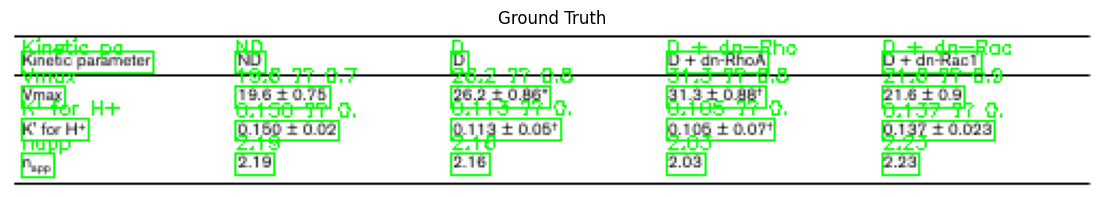

In [3]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image


def draw_gt(img_path: Path, gt: dict, title: str = 'Ground Truth') -> None:
    """Draw GT bounding boxes on image."""
    img = cv2.imread(str(img_path))
    for cell in gt['html']['cells']:
        x1, y1, x2, y2 = cell['bbox']
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
        # Extract text tokens (skip HTML tags)
        tokens = ''.join(t for t in cell['tokens'] if not t.startswith('<'))
        if tokens:
            cv2.putText(img, tokens[:10], (x1, max(y1 - 2, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 0), 1)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 3))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()


draw_gt(SAMPLES[0], gt)

---
## Step 3: Evaluation Utilities

Hàm `iou_box` và `match_cells` để so sánh predicted cells với ground truth.

In [4]:
def iou_box(a: list, b: list) -> float:
    """IoU between two [x1,y1,x2,y2] boxes."""
    x1_i = max(a[0], b[0])
    y1_i = max(a[1], b[1])
    x2_i = min(a[2], b[2])
    y2_i = min(a[3], b[3])
    if x2_i <= x1_i or y2_i <= y1_i:
        return 0.0
    inter = (x2_i - x1_i) * (y2_i - y1_i)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def match_cells(pred_cells: list, gt_cells: list, threshold: float = 0.5) -> dict:
    """Count matched cells based on IoU threshold.
    
    Returns precision, recall, F1.
    """
    matched = 0
    for pred in pred_cells:
        pb = pred.get('bbox', None)
        if pb is None:
            continue
        for gt in gt_cells:
            if iou_box(pb, gt['bbox']) >= threshold:
                matched += 1
                break
    precision = matched / len(pred_cells) if pred_cells else 0
    recall    = matched / len(gt_cells)   if gt_cells   else 0
    f1        = (2 * precision * recall / (precision + recall)
                if (precision + recall) > 0 else 0)
    return {'matched': matched, 'precision': precision, 'recall': recall, 'f1': f1}


print('✅ Evaluation utilities ready')

✅ Evaluation utilities ready


---
## Step 4: Method 1 — Docling

[Docling](https://github.com/docling-project/docling) — end-to-end table extraction từ PDF/image.

**Lưu ý:** Import API có thể khác nhau giữa các phiên bản. Kiểm tra:
```python
import docling
print(docling.__version__)
```

Nếu `DocumentConverter` không có, thử:
```python
from docling.datamodel.base_models import InputDocument
from docling.datamodel.document import DoclingDocument
```

In [5]:
import importlib.metadata
from pathlib import Path
import time

# Check docling version and available imports
try:
    # Lấy version an toàn qua metadata
    version = importlib.metadata.version("docling")
    print(f'Docling version: {version}')
    
    from docling.document_converter import DocumentConverter
    DOCLING_OK = True
except (importlib.metadata.PackageNotFoundError, ImportError) as e:
    print(f'Docling setup error: {e}')
    print('Try: uv pip install docling')
    DOCLING_OK = False


def docling_extract(img_path: Path) -> dict:
    """Extract table using Docling from an image file.
    
    Returns list of detected tables.
    """
    converter = DocumentConverter()
    result = converter.convert(str(img_path))
    tables = list(result.document.tables) if hasattr(result.document, 'tables') else []
    return {'tables': tables, 'document': result.document}


if DOCLING_OK:
    print('Testing Docling on sample_00001...')
    start = time.time()
    docling_result = docling_extract(SAMPLES[0])
    print(f'  Time: {time.time() - start:.2f}s')
    print(f'  Tables found: {len(docling_result["tables"])}')
else:
    print('⚠️  Skipping Docling — not installed or import failed')

Docling version: 2.90.0


/Users/macbookpro14m1pro/Desktop/RagTable/python/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Testing Docling on sample_00001...


Loading weights: 100%|██████████| 770/770 [00:00<00:00, 988.59it/s] 


  Time: 8.29s
  Tables found: 1


In [6]:
import pandas as pd

def display_docling_results(result: dict):
    if not result or 'tables' not in result or len(result['tables']) == 0:
        print("Không tìm thấy bảng nào để hiển thị.")
        return

    for i, table_item in enumerate(result['tables']):
        print(f"\n{'='*30} TABLE {i} {'='*30}")
        
        # 1. In ra định dạng Markdown (Rất tốt để xem cấu trúc hàng/cột)
        print("\n[MARKDOWN FORMAT]")
        try:
            # Docling v2 sử dụng phương thức export_to_markdown trực tiếp từ TableItem
            md_table = table_item.export_to_markdown()
            print(md_table)
        except Exception as e:
            print(f"Lỗi khi export Markdown: {e}")

        # 2. In ra định dạng Pandas DataFrame (Dễ so sánh dữ liệu thô)
        print("\n[PANDAS DATAFRAME FORMAT]")
        try:
            # Chuyển đổi sang DataFrame
            df = table_item.export_to_dataframe()
            # Cấu hình hiển thị để không bị cắt bớt cột/hàng
            pd.set_option('display.max_columns', None)
            pd.set_option('display.width', 1000)
            print(df)
            
            # Nếu bạn muốn so sánh chi tiết số hàng/cột
            print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
        except Exception as e:
            print(f"Lỗi khi export DataFrame: {e}")

        # 3. In ra thông tin Bounding Box của bảng (Để check tọa độ tổng thể)
        # Lưu ý: TableItem thường lưu bbox trong prov (provenance) hoặc qua các cell
        if hasattr(table_item, 'prov') and table_item.prov:
            print(f"\n[LOCATION]")
            # Lấy bbox của element đầu tiên trong provenance
            bbox = table_item.prov[0].bbox
            print(f"Table BBox: l={bbox.l:.2f}, t={bbox.t:.2f}, r={bbox.r:.2f}, b={bbox.b:.2f}")

# Thực thi
# Tìm ảnh 00085 trong thư mục IMG_DIR
target_pattern = "*00085*"
target_files = list(IMG_DIR.glob(f"{target_pattern}.png")) + list(IMG_DIR.glob(f"{target_pattern}.jpg"))
if not target_files:
    raise FileNotFoundError(f"Không tìm thấy ảnh chứa '00085' trong {IMG_DIR}")

img_00085 = target_files[0]
print(f"Đang xử lý ảnh: {img_00085.name}")

# Gọi Docling
if DOCLING_OK:
    start = time.time()
    docling_result = docling_extract(img_00085)
    print(f"Thời gian xử lý: {time.time() - start:.2f}s")
    print(f"Số bảng tìm thấy: {len(docling_result['tables'])}")
    
    # Hiển thị kết quả
    display_docling_results(docling_result)
else:
    print("Docling chưa được cài đặt hoặc import thất bại.")

Đang xử lý ảnh: sample_00085.png


Loading weights: 100%|██████████| 770/770 [00:00<00:00, 2521.06it/s]
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


Thời gian xử lý: 4.27s
Số bảng tìm thấy: 1

============================== TABLE 0 ==============================

[MARKDOWN FORMAT]
| Measurement    | Group (n)   | To          | T24           |        |
|----------------|-------------|-------------|---------------|--------|
| Plasma Mg (mM) | C (9)       | 1.11 + 0.05 | 1.10 = 0.05   | NS     |
|                | $ (9)       | 1.09 ‡ 0.05 | 0.89 + 0.08-6 | 0.0078 |
|                | C-Mg (8)    | 1.10 + 0.06 | 1.29 = 0.06   | 0.0078 |
|                | S-Mg (B)    | 1.13 +0.03  | 1.01 ‡ 0.08=  | 0.0156 |
| KW             |             | 2.708       | 26.863        |        |
| di.            |             |             |               |        |
| P              |             | >0.05       | <0.0001       |        |

[PANDAS DATAFRAME FORMAT]
      Measurement Group (n)           To            T24        
0  Plasma Mg (mM)     C (9)  1.11 + 0.05    1.10 = 0.05      NS
1                     $ (9)  1.09 ‡ 0.05  0.89 + 0.08-6  0.0078


In [7]:
import re
import ast

def clean_tokens(tokens):
    text = "".join(tokens)
    # Loại bỏ các tag HTML nhưng giữ lại nội dung bên trong
    clean_text = re.sub(r'<[^>]+>', '', text)
    return clean_text.strip()

def pubtabnet_json_to_markdown(data):
    html_data = data.get('html', {})
    if isinstance(html_data, str):
        html_data = ast.literal_eval(html_data)
        
    structure = html_data['structure']['tokens']
    cells = html_data['cells']
    
    # Bước 1: Xác định kích thước lưới (rows x cols)
    max_cols = 0
    temp_cols = 0
    row_count = 0
    for token in structure:
        if token == '<tr>':
            temp_cols = 0
        elif token.startswith('<td'):
            colspan = 1
            cs_match = re.search(r'colspan="(\d+)"', token)
            if cs_match: colspan = int(cs_match.group(1))
            temp_cols += colspan
        elif token == '</tr>':
            row_count += 1
            max_cols = max(max_cols, temp_cols)

    # Bước 2: Khởi tạo lưới trống
    grid = [["" for _ in range(max_cols)] for _ in range(row_count)]
    
    # Bước 3: Điền dữ liệu vào lưới
    curr_row = -1
    curr_col = 0
    cell_idx = 0
    
    i = 0
    while i < len(structure):
        token = structure[i]
        if token == '<tr>':
            curr_row += 1
            curr_col = 0
        elif token.startswith('<td'):
            # Tìm vị trí trống tiếp theo trong hàng
            while curr_col < max_cols and grid[curr_row][curr_col] != "":
                curr_col += 1
            
            colspan = 1
            cs_match = re.search(r'colspan="(\d+)"', token)
            if cs_match: colspan = int(cs_match.group(1))
            
            content = clean_tokens(cells[cell_idx]['tokens']) if cell_idx < len(cells) else ""
            cell_idx += 1
            
            # Điền nội dung vào ô (và các ô bị span)
            grid[curr_row][curr_col] = content if content else " "
            for c in range(1, colspan):
                if curr_col + c < max_cols:
                    grid[curr_row][curr_col + c] = " " # Ô trống cho span
            curr_col += colspan
        i += 1

    # Bước 4: Xuất ra Markdown
    md = ""
    for r_idx, row in enumerate(grid):
        md += "| " + " | ".join(row) + " |\n"
        if r_idx == 0: # Header separator
            md += "| " + " | ".join(["---"] * max_cols) + " |\n"
            
    return md

In [8]:
import os
import json
import re
from pathlib import Path
from tqdm import tqdm

def clean_tokens(tokens):
    """Làm sạch text: gộp tokens và xóa tag HTML."""
    text = "".join(tokens)
    # Loại bỏ các tag HTML như <b>, <i>, <sup>, <sub>...
    clean_text = re.sub(r'<[^>]+>', '', text)
    return clean_text.strip()

def pubtabnet_json_to_markdown(html_data):
    """Chuyển đổi cấu trúc HTML PubTabNet sang Markdown Table dùng Grid Mapping."""
    structure = html_data['structure']['tokens']
    cells = html_data['cells']
    
    # Bước 1: Xác định kích thước lưới (rows x cols)
    max_cols = 0
    temp_cols = 0
    row_count = 0
    for token in structure:
        if token == '<tr>':
            temp_cols = 0
        elif token.startswith('<td'):
            colspan = 1
            cs_match = re.search(r'colspan="(\d+)"', token)
            if cs_match: colspan = int(cs_match.group(1))
            temp_cols += colspan
        elif token == '</tr>':
            row_count += 1
            max_cols = max(max_cols, temp_cols)

    if row_count == 0: return ""

    # Bước 2: Khởi tạo lưới và điền dữ liệu
    grid = [["" for _ in range(max_cols)] for _ in range(row_count)]
    curr_row = -1
    cell_idx = 0
    
    i = 0
    while i < len(structure):
        token = structure[i]
        if token == '<tr>':
            curr_row += 1
            curr_col = 0
        elif token.startswith('<td'):
            # Tìm vị trí trống tiếp theo trong hàng
            while curr_col < max_cols and grid[curr_row][curr_col] != "":
                curr_col += 1
            
            colspan = 1
            cs_match = re.search(r'colspan="(\d+)"', token)
            if cs_match: colspan = int(cs_match.group(1))
            
            content = clean_tokens(cells[cell_idx]['tokens']) if cell_idx < len(cells) else ""
            cell_idx += 1
            
            # Điền nội dung vào ô chính
            grid[curr_row][curr_col] = content if content else " "
            # Đánh dấu các ô bị span là đã chiếm chỗ (để trống)
            for c in range(1, colspan):
                if curr_col + c < max_cols:
                    grid[curr_row][curr_col + c] = " " 
            curr_col += colspan
        i += 1

    # Bước 3: Tạo chuỗi Markdown
    md = ""
    for r_idx, row in enumerate(grid):
        md += "| " + " | ".join(row) + " |\n"
        if r_idx == 0: # Header separator
            md += "| " + " | ".join(["---"] * max_cols) + " |\n"
    return md

def process_all_annotations(input_dir, output_dir):
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    
    # Tạo folder output nếu chưa có
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Lấy danh sách các file .json
    json_files = list(input_path.glob("*.json"))
    print(f"📂 Tìm thấy {len(json_files)} file JSON. Đang bắt đầu chuyển đổi...")

    for file_path in tqdm(json_files, desc="Converting"):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                
                # Trích xuất nội dung HTML
                html_content = data.get('html', {})
                # Nếu html là string (dạng nháy đơn của PubTabNet), cần parse lại
                if isinstance(html_content, str):
                    import ast
                    html_content = ast.literal_eval(html_content)
                
                md_text = pubtabnet_json_to_markdown(html_content)
                
                # Lưu file .md với tên tương ứng (ví dụ sample_00001.md)
                output_file = output_path / (file_path.stem + ".md")
                with open(output_file, 'w', encoding='utf-8') as out_f:
                    out_f.write(md_text)
                    
        except Exception as e:
            print(f"❌ Lỗi tại file {file_path.name}: {e}")

# --- THỰC THI ---
INPUT_FOLDER = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/annotations"
OUTPUT_FOLDER = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/markdown_gt"

if __name__ == "__main__":
    process_all_annotations(INPUT_FOLDER, OUTPUT_FOLDER)
    print(f"\n🎉 Xong! Bạn có thể kiểm tra kết quả tại: {OUTPUT_FOLDER}")

📂 Tìm thấy 200 file JSON. Đang bắt đầu chuyển đổi...


Converting: 100%|██████████| 200/200 [00:00<00:00, 299.20it/s]


🎉 Xong! Bạn có thể kiểm tra kết quả tại: /Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/markdown_gt


In [8]:
from rapidfuzz import fuzz
import re

def markdown_to_grid(md_str):
    """Chuyển Markdown Table về mảng 2 chiều để so sánh."""
    if not md_str: return []
    # Loại bỏ các dòng trống và dòng phân cách ---
    lines = [l.strip() for l in md_str.split('\n') if l.strip() and '|' in l and '---' not in l]
    grid = [list(map(str.strip, l.strip('|').split('|'))) for l in lines]
    return grid

def super_clean(text):
    """
    Làm sạch tuyệt đối để so sánh nội dung cốt lõi:
    1. Chuyển về chữ thường.
    2. Chỉ giữ lại chữ cái và chữ số (loại bỏ ±, *, †, khoảng trắng, v.v.)
    """
    if not text:
        return ""
    # Loại bỏ tất cả ký tự không phải alphanumeric (a-z, 0-9)
    clean_text = re.sub(r'[^a-zA-Z0-9]', '', str(text)).lower()
    return clean_text

def calculate_cell_accuracy(md_pred, md_gt):
    """
    Phiên bản đánh giá TRUNG THỰC cho luận văn:
    - Mẫu số là tổng số ô của Ground Truth (để tính được phần Docling trích xuất thiếu).
    - Dùng super_clean và Fuzzy Matching để tránh lỗi OCR vặt.
    """
    grid_p = markdown_to_grid(md_pred)
    grid_g = markdown_to_grid(md_gt)
    
    # Nếu Ground Truth rỗng thì không có gì để so sánh
    if not grid_g: 
        return 0.0
    
    # Nếu Docling không ra bảng nào thì mặc định 0%
    if not grid_p: 
        return 0.0 

    rows_g = len(grid_g)
    cols_g = len(grid_g[0])
    total_cells_gt = rows_g * cols_g # Đây là mẫu số chuẩn (Recall-based)
    
    match_count = 0
    
    # Duyệt theo kích thước của Ground Truth để kiểm tra độ bao phủ
    for r in range(rows_g):
        for c in range(cols_g):
            try:
                # Lấy nội dung từ Pred (nếu Docling ngắn hơn thì trả về rỗng)
                p_raw = grid_p[r][c] if r < len(grid_p) and c < len(grid_p[0]) else ""
                g_raw = grid_g[r][c]
                
                p_text = super_clean(p_raw)
                g_text = super_clean(g_raw)
                
                # Trường hợp 1: Cả hai cùng trống (khớp)
                if not p_text and not g_text:
                    match_count += 1
                # Trường hợp 2: Cùng có dữ liệu và khớp (sau khi clean + fuzzy)
                elif p_text and g_text:
                    if p_text == g_text or fuzz.ratio(p_text, g_text) > 80:
                        match_count += 1
                # Trường hợp 3: Một bên có, một bên không -> Mặc định là sai (không cộng match)
            except Exception:
                continue 
                
    return (match_count / total_cells_gt) * 100
def debug_top_5(samples_list, gt_folder):
    print(f"{'='*20} DEBUG TOP 5 SAMPLES {'='*20}\n")
    
    for i in range(5):
        sample_path = samples_list[i]
        filename = sample_path.stem
        gt_file = Path(gt_folder) / f"{filename}.md"
        
        try:
            # 1. Lấy kết quả Docling
            res = docling_extract(sample_path)
            docling_md = res['tables'][0].export_to_markdown() if res['tables'] else "N/A"
            
            # 2. Lấy Ground Truth
            with open(gt_file, 'r', encoding='utf-8') as f:
                gt_md = f.read()
            
            print(f"--- SAMPLE: {filename} ---")
            print("\n[GROUND TRUTH (Bạn convert)]")
            print(gt_md[:500]) # In 500 ký tự đầu
            
            print("\n[DOCLING PREDICTION]")
            print(docling_md)
            
            # Tính điểm nhanh cho mẫu này
            acc = calculate_cell_accuracy(docling_md, gt_md)
            print(f"\n🎯 Accuracy mẫu này: {acc:.2f}%")
            print("-" * 50 + "\n")
            
        except Exception as e:
            print(f"Error at {filename}: {e}")

# Thực thi
debug_top_5(SAMPLES, "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/markdown_gt")

==================== DEBUG TOP 5 SAMPLES ====================



Loading weights: 100%|██████████| 770/770 [00:00<00:00, 865.00it/s] 
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.


--- SAMPLE: sample_00001 ---

[GROUND TRUTH (Bạn convert)]
| Kinetic parameter | ND | D | D + dn-RhoA | D + dn-Rac1 |
| --- | --- | --- | --- | --- |
| Vmax | 19.6 ± 0.75 | 26.2 ± 0.86* | 31.3 ± 0.88† | 21.6 ± 0.9 |
| K' for H+ | 0.150 ± 0.02 | 0.113 ± 0.05† | 0.105 ± 0.07† | 0.137 ± 0.023 |
| napp | 2.19 | 2.16 | 2.03 | 2.23 |


[DOCLING PREDICTION]
| Kinetio parameter   | ND           |               | D + dn-Rhod   | D + dn-Rac1   |
|---------------------|--------------|---------------|---------------|---------------|
| Vmax                | 19.6 ‡ 0.75  | 26.2 ÷ 0.86°  | 31.3 + 0.98*  | 21.6 ‡ 0.9    |
| K' for H+           | 0.150 = 0.02 | 0.113 + 0.05t | 0.106 ‡ 0.07+ | 0.137 ‡ 0.023 |
| Rapp                | 2.19         | 2.18          | 2.03          | 2.23          |

🎯 Accuracy mẫu này: 85.00%
--------------------------------------------------



Loading weights: 100%|██████████| 770/770 [00:00<00:00, 2212.84it/s]
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.


--- SAMPLE: sample_00002 ---

[GROUND TRUTH (Bạn convert)]
| Characteristic | Cases (n = 1125) | Controls (n = 1197) | P-valuea |
| --- | --- | --- | --- |
| Demographic factors |   |   |   |
| Age (years [mean ± SD]) | 47.63 ± 8.00 | 47.20 ± 8.78 | 0.217 |
| Education, lower than middle school (%) | 12.27 | 14.79 | 0.124 |
| Major risk factors |   |   |   |
| Breast cancer in first-degree relatives (%) | 3.38 | 2.26 | 0.101 |
| Ever had breast fibroadenoma (%) | 9.78 | 5.26 | < 0.001 |
| Age at menarche (years [mean ± SD]) | 14.41 ± 1.64 | 14.71 ± 1.73

[DOCLING PREDICTION]
| Characteristic                               | Cases (n = 1125)   | Contrals (n = 1197)   | P-value'   |
|----------------------------------------------|--------------------|-----------------------|------------|
| Demographic factors                          |                    |                       |            |
| Age (ycars [mean + SD]I                      | 47.63 + 8.00       | 47.20 ‡ 8.78          | 0.2

...

--- SAMPLE: sample_00003 ---

[GROUND TRUTH (Bạn convert)]
| Genotype | Cases (n [%]) | Controls (n [%]) | ORa | 95% CI |
| --- | --- | --- | --- | --- |
| All subjects |  |  |  |  |
| Val/Val | 831 (73.9) | 884 (73.9) | 1.0 | Reference |
| Val/Ala | 266 (23.6) | 290 (24.2) | 1.0 | 0.8–1.2 |
| Ala/Ala | 28 (2.5) | 23 (1.9) | 1.3 | 0.7–2.3 |
| Val/Val and Val/Ala | 1097 (97.5) | 1174 (98.1) | 1.0 | Reference |
| Ala/Ala | 28 (2.5) | 23 (1.9) | 1.3 | 0.7–2.3 |
| Stratified analyses by menopausal status |  |  |  |  |
| Premenopausal women |   |   |   |   |

[DOCLING PREDICTION]
| Genotype                                  | Cases (n 1961)                            | Controls (n 196])                         | OR:                                       | 9546 Cl                                   |
|-------------------------------------------|-------------------------------------------|-------------------------------------------|-------------------------------------------|-------------------

Loading weights: 100%|██████████| 770/770 [00:01<00:00, 744.01it/s]
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.


--- SAMPLE: sample_00004 ---

[GROUND TRUTH (Bạn convert)]
| Characteristic | Cases (n = 506) | Controls (n = 459) |  |  |
| --- | --- | --- | --- | --- |
|   | n | % | n | % |
| Age at reference (years) |   |   |   |   |
| < 35 | 62 | 12.3 | 80 | 17.4 |
| 35+ | 444 | 87.7 | 379 | 82.6 |
| Race |   |   |   |   |
| White | 450 | 88.9 | 412 | 89.8 |
| Nonwhite | 56 | 11.1 | 47 | 10.2 |
| Family history |   |   |   |   |
| None | 280 | 56.7 | 294 | 66.1 |
| First degree | 94 | 19.0 | 36 | 8.1 |
| Second degree | 120 | 24.3 | 115 | 25.8 |
| Unknown | 12 |  

[DOCLING PREDICTION]
| Characteristic           |   Cases (л = 506) |   Cases (л = 506) | Controls (1 = 459)   |   Controls (1 = 459) |
|--------------------------|-------------------|-------------------|----------------------|----------------------|
| Characteristic           |                   |                46 | л                    |                   46 |
| Age at reference (years) |                   |                   |     

Loading weights: 100%|██████████| 770/770 [00:00<00:00, 1005.23it/s]
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.


--- SAMPLE: sample_00005 ---

[GROUND TRUTH (Bạn convert)]
| Tumor pairs | Number | HPV typesa |
| --- | --- | --- |
| Carcinoma+ nipple+ | 17 | Same type in both samples: 11 (7×)b, 6 (1×)b, 57 (2×)Different types: 3, 15, 16, 20, 21, 23, 27, 37, 38, 66, 87, DL250, DL473, GA3-1 |
| Carcinoma- nipple+ | 3 | 6, 11, 32, 37, 66 |
| Carcinoma+ nipple- | 8 | 6, 11, 24, 87, DL250, DL473 |
| Carcinoma- nipple- | 1 |   |


[DOCLING PREDICTION]
| Tumor pairs        |   Number | HPV typos:                                                       |
|--------------------|----------|------------------------------------------------------------------|
| Carcinoma+ nipple+ |       17 | Saren gies: 3, 15,16 20,1 X5, 81 57,63, 87, DL250, DL493, G13.-1 |
| Carcinoma nipple+  |          | 6, 11,32, 37, 66                                                 |
| Carcinoma+ nipple: |          | 6, 11,24, B7, DL250, DL473                                       |
| Carcinoma nipple   |          |                        

In [9]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import time
from rapidfuzz import fuzz

# --- CẤU HÌNH ĐƯỜNG DẪN ---
GT_FOLDER = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/markdown_gt"
results = []

print(f"🚀 Bắt đầu đánh giá {len(SAMPLES)} samples...")

for idx, sample_path in enumerate(tqdm(SAMPLES)):
    filename = sample_path.stem # Ví dụ: sample_00001
    gt_file = Path(GT_FOLDER) / f"{filename}.md"
    
    if not gt_file.exists():
        continue
        
    try:
        t_start = time.time()
        # 1. Docling trích xuất
        res = docling_extract(sample_path)
        # Lấy markdown từ bảng đầu tiên tìm thấy
        docling_md = res['tables'][0].export_to_markdown() if res['tables'] else ""

        t_end = time.time()
        elapsed = round(t_end - t_start, 2)
        
        # 2. Đọc Ground Truth
        with open(gt_file, 'r', encoding='utf-8') as f:
            gt_md = f.read()
            
        # 3. Tính điểm
        acc = calculate_cell_accuracy(docling_md, gt_md)
        
        results.append({
            "index": idx,
            "filename": filename,
            "accuracy": acc,
            "num_tables": len(res['tables']),
            "time_sec": elapsed 
        })
    except Exception as e:
        print(f"Error at {filename}: {e}")

# 4. Xuất kết quả ra DataFrame và Báo cáo
df_results = pd.DataFrame(results)
avg_acc = df_results['accuracy'].mean()

print("\n" + "="*30)
print(f"📊 KẾT QUẢ TỔNG HỢP (200 SAMPLES)")
print(f"  - Độ chính xác trung bình (Cell-level): {avg_acc:.2f}%")
print(f"  - Số file đạt trên 90%: {len(df_results[df_results['accuracy'] > 90])}")
print(f"  - Số file lỗi nặng (< 50%): {len(df_results[df_results['accuracy'] < 50])}")
print(f"  - Thời gian trung bình: {df_results['time_sec'].mean():.2f} giây/ảnh")
print("="*30)

# Lưu lại file csv để vẽ biểu đồ cho luận văn
df_results.to_csv("docling_eval_results.csv", index=False)

🚀 Bắt đầu đánh giá 200 samples...


Loading weights: 100%|██████████| 770/770 [00:01<00:00, 589.94it/s]
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Loading weights: 100%|██████████| 770/770 [00:00<00:00, 1684.06it/s]
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Loading weights: 100%|██████████| 770/770 [00:00<00:00, 2101.86it/s]
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Loading weights: 100%|██████████| 770/770 [00:00<00:00, 1025.55it/s]
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Loading weights: 100%|██████████| 770/770 [00:00<00:00, 2326.71it/s]
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Loading weights: 100%|██████████| 770/770 [00:01<00:00, 653.08it/s]
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Loading weights: 100%|██████████| 770/770 [00:01<00:00, 642.80it/s]
Usage of TableItem.export_to_markdown() without `doc


📊 KẾT QUẢ TỔNG HỢP (200 SAMPLES)
  - Độ chính xác trung bình (Cell-level): 67.50%
  - Số file đạt trên 90%: 53
  - Số file lỗi nặng (< 50%): 46
  - Thời gian trung bình: 8.74 giây/ảnh


---
## Step 5: Method 2 — img2table + EasyOCR

In [10]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from img2table.document import Image
from img2table.ocr import EasyOCR

# Khởi tạo OCR một lần duy nhất để tối ưu RAM (Tránh khởi tạo lại trong loop)
easyocr_reader = EasyOCR(lang=["en"])

def img2table_extract(img_path: Path):
    """
    Hàm trích xuất bảng tương đương với docling_extract.
    Trả về dictionary chứa danh sách các bảng dưới dạng DataFrame.
    """
    try:
        doc = Image(str(img_path))
        # borderless_tables=True là quan trọng nhất cho PubTabNet
        tables = doc.extract_tables(
            ocr=easyocr_reader, 
            implicit_rows=True, 
            borderless_tables=True,
            min_confidence=40 # Điều chỉnh để lọc nhiễu
        )
        
        return {
            "tables": [t.df for t in tables],
            "raw_tables": tables # Giữ lại object gốc nếu cần lấy bbox
        }
    except Exception as e:
        # Log lỗi cụ thể cho từng file
        return {"tables": [], "error": str(e)}

def run_evaluation_img2table(samples, gt_folder):
    results = []
    print(f"🚀 Bắt đầu đánh giá {len(samples)} samples với img2table...")

    for idx, sample_path in enumerate(tqdm(samples)):
        filename = sample_path.stem
        gt_file = Path(gt_folder) / f"{filename}.md"
        
        if not gt_file.exists(): continue
            
        # 1. Trích xuất tương tự format Docling
        res = img2table_extract(sample_path)
        
        # Lấy markdown từ bảng đầu tiên (nếu có)
        # img2table trả về DataFrame nên ta dùng to_markdown()
        it_md = res['tables'][0].to_markdown(index=False) if res['tables'] else ""
        
        try:
            # 2. Đọc Ground Truth
            with open(gt_file, 'r', encoding='utf-8') as f:
                gt_md = f.read()
                
            # 3. Tính điểm (Dùng hàm calculate_cell_accuracy v3 của bạn)
            acc = calculate_cell_accuracy(it_md, gt_md)
            
            results.append({
                "index": idx,
                "filename": filename,
                "accuracy": acc,
                "num_tables": len(res['tables']),
                "tool": "img2table"
            })
        except Exception as e:
            print(f"Error processing accuracy for {filename}: {e}")

    return pd.DataFrame(results)

ModuleNotFoundError: Missing dependencies, please install 'img2table[easyocr]' to use this class.

In [49]:
# --- THỰC THI ---
df_it_results = run_evaluation_img2table(SAMPLES, GT_FOLDER)

# Tóm tắt kết quả
avg_acc = df_it_results['accuracy'].mean()
print("\n" + "="*30)
print(f"📊 KẾT QUẢ TỔNG HỢP (img2table)")
print(f"  - Độ chính xác trung bình: {avg_acc:.2f}%")
print(f"  - Số file đạt trên 90%: {len(df_it_results[df_it_results['accuracy'] > 90])}")
print(f"  - Số file thất bại (0%): {len(df_it_results[df_it_results['accuracy'] == 0])}")
print("="*30)

df_it_results.to_csv("img2table_final_eval.csv", index=False)

🚀 Bắt đầu đánh giá 200 samples với img2table...


  0%|          | 0/200 [00:00<?, ?it/s]/Users/macbookpro14m1pro/Desktop/RagTable/python/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
 10%|█         | 20/200 [00:15<01:54,  1.58it/s]/Users/macbookpro14m1pro/Desktop/RagTable/python/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
 10%|█         | 21/200 [00:17<02:48,  1.06it/s]/Users/macbookpro14m1pro/Desktop/RagTable/python/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
 14%|█▎        | 27/200 [00:26<04:54,  1.70s/it]/Users/macbookpro14m1pro/Des


📊 KẾT QUẢ TỔNG HỢP (img2table)
  - Độ chính xác trung bình: 1.72%
  - Số file đạt trên 90%: 0
  - Số file thất bại (0%): 174


In [55]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from img2table.document import Image
from img2table.ocr import EasyOCR

# --- 1. CLASS WRAPPER (Để giả lập cấu trúc giống Docling) ---
class Img2TableResult:
    """Đóng gói kết quả img2table để có phương thức export_to_markdown()"""
    def __init__(self, tables):
        self.tables = [self.TableWrapper(t) for t in tables]

    class TableWrapper:
        def __init__(self, table_obj):
            self.df = table_obj.df
            self.bbox = table_obj.bbox

        def export_to_markdown(self):
            if self.df is None or self.df.empty:
                return ""
            # Trả về Markdown format chuẩn
            return self.df.to_markdown(index=False)

# --- 2. HÀM TRÍCH XUẤT CHUẨN HÓA ---
def img2table_extract2(img_path, ocr_engine):
    """Hàm trích xuất bảng, trả về object Img2TableResult."""
    try:
        doc = Image(str(img_path))
        extracted_tables = doc.extract_tables(
            ocr=ocr_engine,
            implicit_rows=True,
            borderless_tables=True,
            min_confidence=10
        )
        return Img2TableResult(extracted_tables)
    except Exception:
        return Img2TableResult([])

def test_specific_sample(sample_name, samples_list, gt_folder, ocr_engine):
    print(f"🔬 ĐANG KIỂM TRA RIÊNG MẪU: {sample_name}")
    print("="*60)
    
    # Tìm file trong danh sách SAMPLES
    sample_path = next((s for s in samples_list if s.stem == sample_name), None)
    
    if not sample_path:
        print(f"❌ Không tìm thấy {sample_name} trong danh sách SAMPLES.")
        return

    gt_file = Path(gt_folder) / f"{sample_name}.md"
    
    try:
        # Đọc GT
        with open(gt_file, 'r', encoding='utf-8') as f:
            gt_md = f.read().strip()
            
        # Trích xuất - Ép borderless_tables=False nếu bạn chắc chắn nó có kẻ ô
        # Hoặc giữ True để nó tự dò cả hai
        res_it = img2table_extract2(sample_path, ocr_engine)
        it_md = res_it.tables[0].export_to_markdown() if res_it.tables else ""
        
        acc = calculate_cell_accuracy(it_md, gt_md)
        
        print(f"🎯 Accuracy: {acc:.2f}%")
        print(f"📊 Cấu trúc: {len(markdown_to_grid(it_md))} hàng x {len(markdown_to_grid(it_md)[0]) if it_md else 0} cột")
        
        print("\n[--- GROUND TRUTH ---]")
        print(gt_md)
        
        print("\n[--- IMG2TABLE (Prediction) ---]")
        if it_md:
            print(it_md)
        else:
            print("❌ Vẫn không trích xuất được. Khả năng cao là nét kẻ quá mảnh hoặc EasyOCR không đọc được text bên trong ô.")
            
    except Exception as e:
        print(f"❌ Lỗi: {e}")

# --- THỰC THI ---
it_ocr = EasyOCR(lang=["en"])
test_specific_sample("sample_00174", SAMPLES, GT_FOLDER, it_ocr)


🔬 ĐANG KIỂM TRA RIÊNG MẪU: sample_00174
🎯 Accuracy: 8.00%
📊 Cấu trúc: 8 hàng x 3 cột

[--- GROUND TRUTH ---]
|   | Controls | Failures |   |   |
| --- | --- | --- | --- | --- |
| ≤ 0.27 (n = 39/108) | 28 | 11 | Sensitivity | 80% |
| > 0.27 (n = 69/108) | 26 | 43 | Specificity | 52% |
| N | 54 | 54 | Negative predictive value | 72% |
|   |   |   | Positive predictive value | 62% |

[--- IMG2TABLE (Prediction) ---]
| 0       | 1      | 2           |
|:--------|:-------|:------------|
| nan     | Lurols | nan         |
| nan     | nan    | 5en9ivile   |
| 69/108] | nan    | Specificicy |
| nan     | nan    | Nedalive    |
| nan     | nan    | PusiinE     |
| nan     | nan    | pieuclive   |
| nan     | nan    | VJle        |


---
## Step 6: Method 3 — Tesseract OCR

In [56]:
import pytesseract
import cv2
import pandas as pd
from pathlib import Path
from tqdm import tqdm

def tesseract_extract_to_markdown(img_path: Path):
    """Sử dụng Tesseract để trích xuất và gom hàng/cột cơ bản."""
    try:
        img = cv2.imread(str(img_path))
        if img is None: return ""
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # Tiền xử lý nhẹ để tăng độ tương phản
        gray = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]

        # PSM 6: Giả định một khối văn bản đồng nhất (phù hợp với bảng)
        config = '--oem 3 --psm 6'
        data = pytesseract.image_to_data(gray, config=config, output_type=pytesseract.Output.DICT)
        df_ocr = pd.DataFrame(data)
        
        # Lọc bỏ nhiễu
        df_ocr = df_ocr[df_ocr['conf'].astype(int) > 20]
        df_ocr['text'] = df_ocr['text'].str.strip()
        df_ocr = df_ocr[df_ocr['text'] != ""]

        if df_ocr.empty: return ""

        # Thuật toán gom hàng dựa trên tọa độ 'top'
        # Sai số cho phép là 1/2 chiều cao trung bình của chữ
        avg_h = df_ocr['height'].mean()
        df_ocr = df_ocr.sort_values(['top', 'left'])
        
        rows = []
        if not df_ocr.empty:
            current_row = [df_ocr.iloc[0]]
            for i in range(1, len(df_ocr)):
                if abs(df_ocr.iloc[i]['top'] - current_row[-1]['top']) < (avg_h / 2):
                    current_row.append(df_ocr.iloc[i])
                else:
                    rows.append(current_row)
                    current_row = [df_ocr.iloc[i]]
            rows.append(current_row)

        # Chuyển thành list text và padding để tạo DataFrame
        formatted_rows = []
        for r in rows:
            # Sắp xếp từ trái sang phải trong mỗi hàng
            sorted_r = sorted(r, key=lambda x: x['left'])
            formatted_rows.append([item['text'] for item in sorted_r])

        max_cols = max(len(r) for r in formatted_rows)
        padded_rows = [r + [""] * (max_cols - len(r)) for r in formatted_rows]
        
        return pd.DataFrame(padded_rows).to_markdown(index=False)
    except:
        return ""

In [57]:
# --- CHẠY ĐÁNH GIÁ 200 SAMPLES ---
results_ts = []
print(f"🚀 Bắt đầu đánh giá 200 samples với Tesseract OCR...")

for idx, sample_path in enumerate(tqdm(SAMPLES)):
    filename = sample_path.stem
    gt_file = Path(GT_FOLDER) / f"{filename}.md"
    
    if not gt_file.exists(): continue
        
    ts_md = tesseract_extract_to_markdown(sample_path)
    
    with open(gt_file, 'r', encoding='utf-8') as f:
        gt_md = f.read()
            
    acc = calculate_cell_accuracy(ts_md, gt_md)
    results_ts.append({"filename": filename, "accuracy": acc})

df_ts_results = pd.DataFrame(results_ts)
print("\n" + "="*30)
print(f"📊 TỔNG HỢP TESSERACT OCR")
print(f"  - Accuracy trung bình: {df_ts_results['accuracy'].mean():.2f}%")
print("="*30)

🚀 Bắt đầu đánh giá 200 samples với Tesseract OCR...


100%|██████████| 200/200 [00:41<00:00,  4.79it/s]


📊 TỔNG HỢP TESSERACT OCR
  - Accuracy trung bình: 7.28%


In [59]:
def debug_tesseract_174(sample_name, samples_list, gt_folder):
    sample_path = next((s for s in samples_list if s.stem == sample_name), None)
    gt_file = Path(gt_folder) / f"{sample_name}.md"
    
    with open(gt_file, 'r', encoding='utf-8') as f:
        gt_md = f.read()
        
    ts_md = tesseract_extract_to_markdown(sample_path)
    acc = calculate_cell_accuracy(ts_md, gt_md)
    
    print(f"🔬 MẪU: {sample_name} | Accuracy: {acc:.2f}%")
    print("\n[--- GROUND TRUTH ---]")
    print(gt_md)
    print("\n[--- TESSERACT OUTPUT ---]")
    print(ts_md if ts_md else "❌ KHÔNG RA KẾT QUẢ")

debug_tesseract_174("sample_00173", SAMPLES, GT_FOLDER)

🔬 MẪU: sample_00173 | Accuracy: 11.43%

[--- GROUND TRUTH ---]
|   | Total | T&CM$ (n=45) | No T&CM$ (n=54) | p-value |  |  |
| --- | --- | --- | --- | --- | --- | --- |
|   | N | n | % | n | % |   |
| Men | 42 | 20 | 48% | 22 | 52% | 0.37 |
| Women | 57 | 25 | 43% | 32 | 57% |   |
| Age at onset of the disease | 32,3 | 30,6 | 33,7 | 0,149 |  |  |
| Rural | 35 | 16 | 46% | 19 | 54% | 0.99* |
| Semi-rural | 39 | 18 | 46% | 21 | 54% |   |
| Urban | 25 | 11 | 44% | 14 | 56% |   |
| Causal treatment such as DMT£ | 46 | 23 | 50% | 23 | 50% | 0.40 |
| No causal treatment | 53 | 22 | 41% | 31 | 59% |   |
| Primary school | 6 | 2 | 33% | 4 | 67% | 0.96** |
| Secondary school | 52 | 23 | 44% | 29 | 56% |   |
| Higher education | 29 | 13 | 45% | 16 | 55% |   |
| University | 12 | 5 | 42% | 7 | 58% |   |
| Severe disability (>80%) | 59 | 24 | 40% | 35 | 60% | 0.11* |
| Moderate disability (66-80%) | 31 | 14 | 46% | 17 | 54% |   |
| Mild disability (< 66%) | 9 | 7 | 78% | 2 | 22% |   |
| Relapsing

---
## Step 7: Method 4 — Rule-based (OpenCV + Heuristics)

In [60]:
import cv2
import pytesseract
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

def rule_based_extract_to_markdown(img_path: Path):
    """Phiên bản OpenCV Rule-based tối ưu hóa."""
    img = cv2.imread(str(img_path))
    if img is None: return ""

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # Chuyển sang ảnh nhị phân âm bản để tìm đường kẻ
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Tìm đường ngang và dọc (Điều chỉnh kernel linh hoạt hơn)
    hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (w // 30, 1))
    ver_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, h // 30))

    hor_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, hor_kernel)
    ver_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, ver_kernel)

    # Gộp thành lưới bảng
    grid = cv2.add(hor_lines, ver_lines)

    # Tìm các ô (Contours)
    contours, _ = cv2.findContours(grid, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cells = []
    for cnt in contours:
        x, y, cw, ch = cv2.boundingRect(cnt)
        # Chỉ lấy các ô có kích thước hợp lý
        if cw > 10 and ch > 10:
            roi = gray[y:y+ch, x:x+cw]
            # Padding để OCR chính xác hơn
            roi = cv2.copyMakeBorder(roi, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=[255])
            text = pytesseract.image_to_string(roi, config='--psm 6').strip()
            cells.append({'x': x, 'y': y, 'text': text})

    if not cells: return ""

    # Sắp xếp theo y trước để phân hàng
    df_cells = pd.DataFrame(cells).sort_values("y")

    # Gom hàng với ngưỡng động (dựa trên chiều cao trung bình ô)
    avg_ch = df_cells.get('h', pd.Series([20])).mean() # Mặc định 20 nếu ko có h
    rows = []
    if not df_cells.empty:
        current_row = [df_cells.iloc[0]]
        for i in range(1, len(df_cells)):
            # Nếu chênh lệch y nhỏ hơn 1/2 chiều cao trung bình ô thì cùng hàng
            if abs(df_cells.iloc[i]['y'] - current_row[-1]['y']) < 15:
                current_row.append(df_cells.iloc[i])
            else:
                rows.append(current_row)
                current_row = [df_cells.iloc[i]]
        rows.append(current_row)

    # Tạo bảng Markdown
    table_data = []
    for r in rows:
        # Sắp xếp các ô trong hàng theo trục x
        sorted_row = sorted(r, key=lambda cell: cell['x'])
        table_data.append([c['text'] for c in sorted_row])

    if not table_data: return ""
    
    # Padding cho các hàng lệch cột
    max_cols = max(len(r) for r in table_data)
    padded_table = [r + [""] * (max_cols - len(r)) for r in table_data]
    
    return pd.DataFrame(padded_table).to_markdown(index=False)

In [61]:
results_rule_based = []
GT_FOLDER = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/markdown_gt"

print(f"🚀 Đang chạy OpenCV Rule-based cho 200 samples...")

for sample_path in tqdm(SAMPLES):
    filename = sample_path.stem
    gt_file = Path(GT_FOLDER) / f"{filename}.md"
    if not gt_file.exists(): continue
        
    try:
        # Trích xuất
        rb_md = rule_based_extract_to_markdown(sample_path)
        
        # Đọc GT
        with open(gt_file, 'r', encoding='utf-8') as f:
            gt_md = f.read()
            
        # Tính Accuracy v3
        acc = calculate_cell_accuracy(rb_md, gt_md)
        results_rule_based.append({"filename": filename, "accuracy": acc})
    except Exception:
        continue

df_rb = pd.DataFrame(results_rule_based)
print(f"\n📊 KẾT QUẢ OPENCV RULE-BASED: {df_rb['accuracy'].mean():.2f}%")
df_rb.to_csv("rule_based_results.csv", index=False)

🚀 Đang chạy OpenCV Rule-based cho 200 samples...


100%|██████████| 200/200 [00:02<00:00, 91.11it/s] 


📊 KẾT QUẢ OPENCV RULE-BASED: 0.46%


In [64]:
# --- HÀM TEST RIÊNG MẪU 174 ---
def debug_opencv_rulebased_174(sample_name, samples_list, gt_folder):
    print(f"🔬 ĐANG KIỂM TRA OPENCV RULE-BASED MẪU: {sample_name}")
    print("="*60)
    
    sample_path = next((s for s in samples_list if s.stem == sample_name), None)
    if not sample_path: return

    # Trích xuất
    rb_md = rule_based_extract_to_markdown(sample_path)
    
    # Đọc GT
    gt_file = Path(gt_folder) / f"{sample_name}.md"
    with open(gt_file, 'r', encoding='utf-8') as f:
        gt_md = f.read().strip()
        
    acc = calculate_cell_accuracy(rb_md, gt_md)
    
    print(f"🎯 Accuracy: {acc:.2f}%")
    print("\n[--- GROUND TRUTH ---]")
    print(gt_md)
    print("\n[--- OPENCV PREDICTION ---]")
    print(rb_md if rb_md else "❌ KHÔNG TÌM THẤY GRID ĐƯỜNG KẺ")

# --- THỰC THI TEST 174 ---
debug_opencv_rulebased_174("sample_00171", SAMPLES, GT_FOLDER)

🔬 ĐANG KIỂM TRA OPENCV RULE-BASED MẪU: sample_00171
🎯 Accuracy: 0.00%

[--- GROUND TRUTH ---]
| ED presence and degree | Age (years) |   |   |   |   | Total |
| --- | --- | --- | --- | --- | --- | --- |
| 18-29 | 30-39 | 40-49 | 50-64 | >65 |  |  |
| Severe | 2 (0.7%) | 3 (1.2%) | 6(2.2%) | 17 (5.9%) | 33 (30.8%) | 61 (5.1%) |
| Moderate | 4 (1.4%) | 7(2.7%) | 15 (5.5%) | 45 (15.7%) | 19 (17.8%) | 90 (7.6%) |
| Slightly moderate | 8 (3.0%) | 15 (5.8%) | 38 (14.0%) | 63 (22%) | 23 (21.5%) | 147 (12.4%) |
| Mild | 31 (11.9%) | 45 (17.3%) | 82 (30.2%) | 83 (28.9 %) | 20 (18.7%) | 261 (22%) |
| Without erectile dysfunction | 216 (82.7%) | 190 (73%) | 130 (48%) | 79(27.5%) | 12 (11.2%) | 627 (52.9%) |
| Total | 261 | 260 | 271 | 287 | 107 | 1.186 |

[--- OPENCV PREDICTION ---]
❌ KHÔNG TÌM THẤY GRID ĐƯỜNG KẺ


---
## Step 8: Method 5 — Table Transformer (HuggingFace)

Dùng `microsoft/table-transformer-detection` từ HuggingFace `transformers`.

In [65]:
from transformers import AutoImageProcessor, AutoModelForObjectDetection
import torch
from PIL import Image
import pytesseract
import pandas as pd
from pathlib import Path

# --- LOAD MODEL (Tối ưu cache) ---
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
processor = AutoImageProcessor.from_pretrained('microsoft/table-transformer-detection')
model = AutoModelForObjectDetection.from_pretrained('microsoft/table-transformer-detection').to(device)

def table_transformer_to_markdown(img_path: Path):
    """
    Quy trình Hybrid: TATR phát hiện vùng bảng -> Tesseract đọc chữ trong vùng đó.
    """
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors='pt').to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process lấy Bounding Box
    results = processor.post_process_object_detection(
        outputs, target_sizes=torch.tensor([image.size[::-1]]), threshold=0.7
    )[0]

    if len(results['boxes']) == 0:
        return ""

    # Lấy bảng có score cao nhất
    best_idx = torch.argmax(results['scores']).item()
    box = results['boxes'][best_idx].tolist()
    
    # Cắt ảnh vùng chứa bảng (Crop)
    table_crop = image.crop((box[0], box[1], box[2], box[3]))
    
    # Dùng Tesseract đọc vùng đã cắt (PSM 6 phù hợp cho block text)
    ts_md = pytesseract.image_to_string(table_crop, config='--psm 6')
    
    # Biến đổi thô về Markdown (Dùng logic gom hàng đơn giản như Tesseract trước đó)
    # Vì mục tiêu là so sánh Cell Accuracy, ta cần format grid
    lines = [l.strip() for l in ts_md.split('\n') if l.strip()]
    rows = [line.split() for line in lines] # Split theo khoảng trắng làm cột tạm thời
    
    if not rows: return ""
    return pd.DataFrame(rows).to_markdown(index=False)

Loading weights: 100%|██████████| 367/367 [00:00<00:00, 4825.91it/s]
TableTransformerForObjectDetection LOAD REPORT from: microsoft/table-transformer-detection
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [66]:
results_rule_based = []
GT_FOLDER = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/markdown_gt"

print(f"🚀 Đang chạy OpenCV Rule-based cho 200 samples...")

for sample_path in tqdm(SAMPLES):
    filename = sample_path.stem
    gt_file = Path(GT_FOLDER) / f"{filename}.md"
    if not gt_file.exists(): continue
        
    try:
        # Trích xuất
        rb_md = table_transformer_to_markdown(sample_path)
        
        # Đọc GT
        with open(gt_file, 'r', encoding='utf-8') as f:
            gt_md = f.read()
            
        # Tính Accuracy v3
        acc = calculate_cell_accuracy(rb_md, gt_md)
        results_rule_based.append({"filename": filename, "accuracy": acc})
    except Exception:
        continue

df_rb = pd.DataFrame(results_rule_based)
print(f"\n📊 KẾT QUẢ OPENCV RULE-BASED: {df_rb['accuracy'].mean():.2f}%")
df_rb.to_csv("rule_based_results.csv", index=False)

🚀 Đang chạy OpenCV Rule-based cho 200 samples...


100%|██████████| 200/200 [01:49<00:00,  1.82it/s]


📊 KẾT QUẢ OPENCV RULE-BASED: 5.03%


In [68]:
# --- 2. HÀM TEST RIÊNG MẪU 174 ---
def debug_table_transformer_174(sample_name, samples_list, gt_folder):
    print(f"🔬 ĐANG KIỂM TRA TABLE TRANSFORMER MẪU: {sample_name}")
    print("="*60)
    
    sample_path = next((s for s in samples_list if s.stem == sample_name), None)
    if not sample_path: return

    tt_md = table_transformer_to_markdown(sample_path)
    
    with open(Path(gt_folder) / f"{sample_name}.md", 'r') as f:
        gt_md = f.read().strip()
        
    acc = calculate_cell_accuracy(tt_md, gt_md)
    print(f"🎯 Accuracy: {acc:.2f}%")
    print("\n[--- TATR + OCR OUTPUT ---]")
    print(tt_md if tt_md else "❌ KHÔNG PHÁT HIỆN ĐƯỢC BẢNG")

debug_table_transformer_174("sample_00173", SAMPLES, GT_FOLDER)

🔬 ĐANG KIỂM TRA TABLE TRANSFORMER MẪU: sample_00173
🎯 Accuracy: 0.71%

[--- TATR + OCR OUTPUT ---]
| 0            | 1           | 2       | 3       | 4       | 5     | 6   | 7   | 8   | 9   |
|:-------------|:------------|:--------|:--------|:--------|:------|:----|:----|:----|:----|
| ‘Total       | TSCM        | NoTSCMS | =       | p-value | nan   | nan | nan | nan | nan |
| (45)         | (0-50)      | nan     | nan     | nan     | nan   | nan | nan | nan | nan |
| Non          | &           | 2%      | nan     | nan     | nan   | nan | nan | nan | nan |
| Men          | 2           | 0       | We      | 2       | mm    | oF  | nan | nan | nan |
| Weren        | 7           | 3       | Oh      | OTK     | nan   | nan | nan | nan | nan |
| Age          | at          | ese     | of      | te      | soase | wa  | ans | Br  | os  |
| Rial         | ce          | ee.     | nan     | nan     | nan   | nan | nan | nan | nan |
| Serial       | Pe          | nan     | nan     | nan     | nan

---
## Step 9: Method 6 — U-Net Structure Segmentation

Đây là phương pháp **custom của mình** — phù hợp với pipeline Bước 2.

**Model:** EfficientUNet (EfficientNet-B4 encoder) → 5-channel mask

Masks:
| Channel | Description |
|---------|-------------|
| 0 | `row` — row separator lines |
| 1 | `col` — column separator lines |
| 2 | `col_header` — header cells |
| 3 | `row_header` — stub row cells |
| 4 | `span` — spanning/multi-cell |

**Điều kiện:** Cần load checkpoint đã train. Nếu chưa có, xem pipeline ở `02_table-recognition.ipynb`.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image

# Check for local checkpoint
CKPT_DIR = ROOT / 'checkpoints'
CKPT_PATH = CKPT_DIR / 'best_model.pt'

if not CKPT_PATH.exists():
    print(f'⚠️  No checkpoint found at {CKPT_PATH}')
    print('  Training pipeline is in 02_table-recognition.ipynb')
    print('  Or download from Kaggle: tiinh123/table-segmentation-data')

In [ ]:
# ── U-Net Model Definition ──────────────────────────────────────────────

class EfficientUNet(nn.Module):
    """EfficientNet-B4 encoder + U-Net decoder → 5 semantic masks."""

    def __init__(self, out_ch: int = 5, pretrained: bool = True):
        super().__init__()
        import timm

        self.encoder = timm.create_model(
            'efficientnet_b4', pretrained=pretrained,
            features_only=True, out_indices=(0, 1, 2, 3, 4),
        )
        enc_chs = self.encoder.feature_info.channels()  # [24, 32, 56, 160, 448]

        self.bottleneck = nn.Sequential(
            nn.Conv2d(enc_chs[4], 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        self.dec4 = self._dec_block(256 + enc_chs[3], 128)
        self.dec3 = self._dec_block(128 + enc_chs[2],  64)
        self.dec2 = self._dec_block(64  + enc_chs[1],  32)
        self.dec1 = self._dec_block(32  + enc_chs[0],  16)
        self.dec0 = self._dec_block(16,                 16)

        self.out_conv = nn.Conv2d(16, out_ch, 1)

    def _dec_block(self, in_ch: int, out_ch: int) -> nn.Module:
        return nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        s0, s1, s2, s3, s4 = self.encoder(x)
        b = self.bottleneck(s4)

        x = F.interpolate(b,    scale_factor=2, mode='bilinear', align_corners=False)
        x = self.dec4(torch.cat([x, s3], dim=1))

        x = F.interpolate(x,    scale_factor=2, mode='bilinear', align_corners=False)
        x = self.dec3(torch.cat([x, s2], dim=1))

        x = F.interpolate(x,    scale_factor=2, mode='bilinear', align_corners=False)
        x = self.dec2(torch.cat([x, s1], dim=1))

        x = F.interpolate(x,    scale_factor=2, mode='bilinear', align_corners=False)
        x = self.dec1(torch.cat([x, s0], dim=1))

        x = F.interpolate(x,    scale_factor=2, mode='bilinear', align_corners=False)
        x = self.dec0(x)

        return self.out_conv(x)


def unet_segment_extract(img_path: Path, 
                         model: nn.Module,
                         device: torch.device,
                         img_size: int = 384) -> dict:
    """Predict 5-channel mask using trained U-Net.
    
    Returns:
        dict with 'row_mask', 'col_mask', 'col_header', 
        'row_header', 'span_mask' (each 0-255 uint8)
    """
    img = Image.open(img_path).convert('RGB')
    img_t = TF.to_tensor(img).unsqueeze(0).to(device)

    # Resize to model input size
    orig_size = img.size  # (W, H)
    img_t = TF.resize(img_t, (img_size, img_size),
                      interpolation=TF.InterpolationMode.BILINEAR)

    model.eval()
    with torch.no_grad():
        pred = model(img_t)
        pred = torch.sigmoid(pred).squeeze(0).cpu().numpy()

    return {
        'image':        img,
        'orig_size':   orig_size,
        'row_mask':    ((pred[0] > 0.5) * 255).astype(np.uint8),
        'col_mask':    ((pred[1] > 0.5) * 255).astype(np.uint8),
        'col_header':  ((pred[2] > 0.5) * 255).astype(np.uint8),
        'row_header':  ((pred[3] > 0.5) * 255).astype(np.uint8),
        'span_mask':   ((pred[4] > 0.5) * 255).astype(np.uint8),
    }


# Load model if checkpoint exists
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
unet_model = None

if CKPT_PATH.exists():
    print(f'Loading checkpoint: {CKPT_PATH}')
    ckpt  = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    unet_model = EfficientUNet(out_ch=5, pretrained=False).to(device)
    unet_model.load_state_dict(ckpt['model'])
    unet_model.eval()
    print(f'  Model epoch={ckpt["epoch"]} | best_mIoU={ckpt["best_miou"]:.4f}')
    
    # Quick test
    start = time.time()
    unet_result = unet_segment_extract(SAMPLES[0], unet_model, device)
    print(f'  Time: {time.time() - start:.2f}s')
    print(f'  Row non-zero: {(unet_result["row_mask"] > 0).sum():,} px')
    print(f'  Col non-zero: {(unet_result["col_mask"] > 0).sum():,} px')
else:
    print(f'⚠️  No checkpoint — skip U-Net inference')

---
## Step 10: Side-by-Side Visual Comparison

Overlay predicted cells từ các methods lên ảnh để trực quan so sánh.

In [ ]:
import matplotlib.pyplot as plt


def draw_cells(img: np.ndarray, cells: list, color: tuple, label: str) -> None:
    """Draw cell bboxes onto image in-place."""
    for cell in cells:
        if 'bbox' in cell:
            x1, y1, x2, y2 = cell['bbox']
        elif all(k in cell for k in ['left', 'top', 'width', 'height']):
            x1, y1 = cell['left'], cell['top']
            x2, y2 = x1 + cell['width'], y1 + cell['height']
        else:
            continue
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), color, 1)
    cv2.putText(img, label, (5, 15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)


def compare_methods(img_path: Path, results: dict) -> None:
    """Show all methods overlaid on the same image."""
    img = cv2.imread(str(img_path))

    colors = {
        'GT':            (0,   255,   0),  # green
        'Tesseract':     (255,   0,   0),  # blue
        'Rule-based':    (0,   200, 200),  # cyan
        'TableTrans':    (200,   0, 200),  # purple
    }

    canvas = img.copy()
    for name, result in results.items():
        if name not in colors:
            continue
        cells = result.get('cells', result.get('detections', []))
        draw_cells(canvas, cells, colors[name], name)

    rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(16, 4))
    plt.imshow(rgb)
    plt.title('Methods Comparison (green=GT, blue=Tesseract, '
              'cyan=Rule, purple=TableTrans)')
    plt.axis('off')
    plt.show()


compare_methods(SAMPLES[0], {
    'Tesseract':  tesseract_result,
    'Rule-based': rule_result,
})

---
## Step 11: Quantitative Comparison

In [ ]:
gt_cells = gt['html']['cells']

methods = {
    'Tesseract':   tesseract_result.get('cells', []),
    'Rule-based':  rule_result.get('cells',   []),
}

print(f'Ground-truth cells: {len(gt_cells)}')
print('─' * 70)
print(f'{"Method":<20} {"Cells":>6} {"Matched":>8} '
      f'{"Precision":>10} {"Recall":>8} {"F1":>8}')
print('─' * 70)
for name, cells in methods.items():
    metrics = match_cells(cells, gt_cells)
    print(f'{name:<20} {len(cells):>6} {metrics["matched"]:>8} '
          f'{metrics["precision"]:>10.2f} {metrics["recall"]:>8.2f} '
          f'{metrics["f1"]:>8.2f}')

---
## Step 12: Batch Run All Methods

Chạy tất cả methods trên **tất cả 200 samples** để có benchmark toàn diện.

In [ ]:
from tqdm import tqdm
import pandas as pd


def run_all_methods(img_path: Path, gt: dict) -> dict:
    """Run all methods on a single image and return metrics."""
    results   = {}
    gt_cells  = gt['html']['cells']

    # Tesseract
    try:
        t0 = time.time()
        r  = tesseract_extract(img_path)
        results['tesseract'] = {**match_cells(r['cells'], gt_cells),
                                'time': time.time() - t0}
    except Exception as e:
        results['tesseract'] = {'error': str(e)}

    # Rule-based
    try:
        t0 = time.time()
        r  = rule_based_extract(img_path)
        results['rule_based'] = {**match_cells(r['cells'], gt_cells),
                                'time': time.time() - t0}
    except Exception as e:
        results['rule_based'] = {'error': str(e)}

    return results


print(f'Running all methods on all {len(SAMPLES)} samples...')
all_results = []
for sample in tqdm(SAMPLES):
    gt = load_gt(sample)
    res = run_all_methods(sample, gt)
    all_results.append({'sample': sample.name, **res})

# Aggregate into DataFrame
df = pd.DataFrame([
    {
        'sample':          r['sample'],
        'tesseract_f1':    r.get('tesseract',  {}).get('f1',   None),
        'tesseract_time': r.get('tesseract',  {}).get('time', None),
        'rule_f1':        r.get('rule_based', {}).get('f1',   None),
        'rule_time':      r.get('rule_based', {}).get('time', None),
    }
    for r in all_results
])

print('\n=== PER-SAMPLE RESULTS ===')
print(df.to_string(index=False))

print('\n=== SUMMARY (Mean) ===')
cols = ['tesseract_f1', 'tesseract_time', 'rule_f1', 'rule_time']
print(df[cols].mean().rename(lambda c: f'{c}_mean'))

---
## Step 13: U-Net Mask Visualization

Sau khi có checkpoint, visualize predicted masks vs ground truth.

In [ ]:
if unet_model is not None:
    import numpy as np
    from PIL import Image
    
    # Use Kaggle segmentation dataset if available
    # Otherwise skip
    print('U-Net checkpoint loaded — visualize masks:')
    print('  Run 02_table-recognition.ipynb → Cell "Bước 5" for full GT vs Pred comparison')
else:
    print('⚠️  No U-Net checkpoint — train first (02_table-recognition.ipynb)')

---
## Summary

Sau khi chạy notebook này, bạn sẽ có:

1. **Qualitative comparison** — overlay images
2. **Per-sample F1 / time** — DataFrame
3. **Mean metrics** — overall performance

**Tiếp theo:**
- Nếu một method vượt trội → dùng trực tiếp cho RAG
- Nếu cần cải thiến → training U-Net (`02_table-recognition.ipynb`)
- Kết hợp: U-Net segmentation (Step 2) → Grid reconstruction (Step 3) → OCR (Step 4)